# 04 — Error Analysis: mit javított meg a prompt, és mit rontott el?

Egy leaderboard csak azt mondja meg, hogy melyik sorban nagyobb a szám. Egy AI Engineernek ennél többet kell tudnia: **melyik intentek változtak, milyen hibák maradtak meg, mely sample-eket javítottuk ki, és hol vezettünk be regressziót**.

In [1]:
from pathlib import Path

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "02_notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

print(f"Project root: {PROJECT_ROOT}")

Project root: <PROJECT_ROOT>


## Provider kiválasztása

Az error analysis csak ugyanazon provider/model futásait hasonlíthatja össze. A `LLM_PROVIDER` környezeti változó dönti el, melyik `07_outputs/results/raw/<provider>/` mappát olvassuk.


In [2]:
import os
PROVIDER = os.getenv("LLM_PROVIDER", "mock")
print("Analyzing provider:", PROVIDER)


Analyzing provider: mock


## 1. Benchmark summary és candidate kiválasztása

A baseline mindig P0. Candidate-ként a legmagasabb Macro F1-et elérő promptot választjuk az elemzéshez — de ez még nem jelenti azt, hogy productionban is automatikusan ezt választjuk.

In [3]:
import pandas as pd

summary_path = PROJECT_ROOT / "07_outputs/results/benchmark_summary.csv"
if not summary_path.exists():
    raise FileNotFoundError("Run 05_scripts/09_run_smoke_test.py or 05_scripts/07_generate_report.py first.")

summary = pd.read_csv(summary_path)
summary = summary.sort_values("macro_f1", ascending=False).reset_index(drop=True)
best_strategy = str(summary.iloc[0]["strategy"])
print("Best quality strategy:", best_strategy)
display(summary[["strategy", "accuracy", "macro_f1", "invalid_output_rate", "mean_total_tokens", "p95_latency_seconds", "cost_per_1000_requests_usd"]])


Best quality strategy: p14_tree_branch_vote


,strategy,accuracy,macro_f1,invalid_output_rate,mean_total_tokens,p95_latency_seconds,cost_per_1000_requests_usd
0,p14_tree_branch_vote,0.946667,0.946599,0.000000,1391.506667,1.590605,0.0
1,p16_full_advanced_template,0.916667,0.917515,0.000000,1607.210000,1.082600,0.0
2,p13_reasoning_model,0.893333,0.894515,0.000000,489.903333,0.820710,0.0
3,p5_decision_policy,0.836667,0.844015,0.013333,1333.830000,0.887315,0.0
4,p15_grammar_constrained,0.833333,0.834862,0.000000,325.886667,0.493810,0.0
5,p7_structured_output,0.823333,0.826353,0.000000,1325.580000,0.902725,0.0
6,p6_json,0.806667,0.821044,0.030000,1371.563333,0.894540,0.0
7,p12_contrastive_few_shot,0.813333,0.818540,0.006667,1317.186667,0.895960,0.0
8,p11_delimited_data,0.810000,0.814141,0.003333,348.233333,0.440805,0.0
9,p4_constraints,0.800000,0.808881,0.013333,1199.526667,0.797800,0.0


## 2. Baseline és candidate raw predictionök összeillesztése

In [4]:
baseline = pd.read_csv(PROJECT_ROOT / "07_outputs/results/raw" / PROVIDER / "p0_zero_shot.csv")
candidate = pd.read_csv(PROJECT_ROOT / "07_outputs/results/raw" / PROVIDER / f"{best_strategy}.csv")

merged = baseline[["sample_id", "text", "true_label", "predicted_label"]].merge(
    candidate[["sample_id", "predicted_label"]],
    on="sample_id",
    suffixes=("_baseline", "_candidate"),
)
merged.head()


,sample_id,text,true_label,predicted_label_baseline,predicted_label_candidate
0,bench_0000,"Hi support, the application crashes whenever i...",technical,NaN,api
1,bench_0001,Could you help? My credit card payment for Bas...,upgrade,NaN,upgrade
2,bench_0002,"Hello, This service has been frustrating for w...",complaint,complaint,complaint
3,bench_0003,"Hello. For context, last month we discussed on...",api,technical,api
4,bench_0004,"Good morning, Where can I find the API documen...",technical,NaN,technical


## 3. Négy sample-level kimenetel

Minden ticket az alábbi négy csoport egyikébe kerül:

1. **Correct in both** — egyik prompt sem változtatott a helyes döntésen;
2. **Fixed by candidate** — baseline rossz volt, candidate javította;
3. **Regression** — baseline jó volt, candidate elrontotta;
4. **Wrong in both** — továbbra is nehéz példa.

Ez lényegesen informatívabb, mint csak a nettó F1 változás.

In [5]:
baseline_correct = merged["predicted_label_baseline"] == merged["true_label"]
candidate_correct = merged["predicted_label_candidate"] == merged["true_label"]

merged["outcome"] = "wrong_in_both"
merged.loc[baseline_correct & candidate_correct, "outcome"] = "correct_in_both"
merged.loc[~baseline_correct & candidate_correct, "outcome"] = "fixed_by_candidate"
merged.loc[baseline_correct & ~candidate_correct, "outcome"] = "regression"

merged["outcome"].value_counts()


outcome
correct_in_both       176
fixed_by_candidate    108
wrong_in_both           8
regression              8
Name: count, dtype: int64

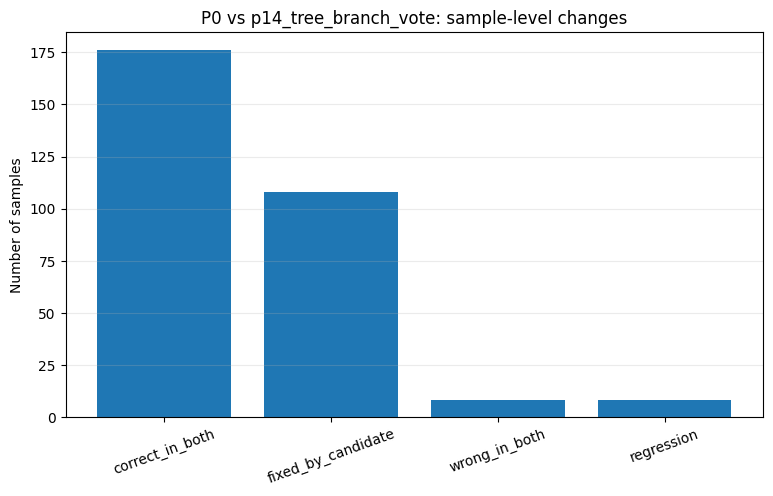

In [6]:
import matplotlib.pyplot as plt

outcome_counts = merged["outcome"].value_counts()
fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(outcome_counts.index, outcome_counts.values)
ax.set_title(f"P0 vs {best_strategy}: sample-level changes")
ax.set_ylabel("Number of samples")
ax.tick_params(axis="x", rotation=20)
ax.grid(axis="y", alpha=0.25)
plt.show()


### Mit keresünk itt?

Egy valóban jobb promptnál azt szeretnénk, hogy a `fixed_by_candidate` szám érdemben meghaladja a `regression` számot. Ha a nettó F1 nő, de sok regresszió keletkezik egy üzletileg kritikus osztályban, azt külön mérlegelni kell.

## 4. Konkrét javított példák

In [7]:
fixed = merged[merged["outcome"] == "fixed_by_candidate"]
fixed[["text", "true_label", "predicted_label_baseline", "predicted_label_candidate"]].head(15)


,text,true_label,predicted_label_baseline,predicted_label_candidate
1,Could you help? My credit card payment for Bas...,upgrade,NaN,upgrade
3,"Hello. For context, last month we discussed on...",api,technical,api
4,"Good morning, Where can I find the API documen...",technical,NaN,technical
10,Two things happened: The response from your te...,technical,NaN,technical
11,"Hello. For context, last month we discussed on...",billing,NaN,billing
14,Could you help? The login page is not working ...,complaint,technical,complaint
17,Could you help? The login page is not working ...,technical,NaN,technical
18,Previous resolved issue: I am extremely disapp...,cancellation,complaint,cancellation
21,"Hello. For context, last month we discussed on...",cancellation,billing,cancellation
33,Could you help? we keep hitting the api rate l...,api,technical,api


## 5. Konkrét regressziók

Ezeket nem szabad elrejteni. Promptoptimalizálásnál gyakori, hogy egy új szabály egyes edge case-eket javít, másokat viszont rossz irányba terel.

In [8]:
regressions = merged[merged["outcome"] == "regression"]
regressions[["text", "true_label", "predicted_label_baseline", "predicted_label_candidate"]].head(15)


,text,true_label,predicted_label_baseline,predicted_label_candidate
95,"Hello. For context, last month we discussed on...",api,api,technical
102,Our team noticed that the webhook signature fo...,api,api,technical
132,"Hi support, I am extremely disappointed with t...",complaint,complaint,technical
159,"Hello, my invoice shows an unexpected $19 char...",billing,billing,cancellation
163,Could you help? We keep hitting the API rate l...,api,api,technical
215,Two things happened: The response from your te...,billing,billing,complaint
216,"Hello, The dashboard freezes after I click on ...",api,api,technical
266,"Hello, how can we move our team to the enterpr...",upgrade,upgrade,billing


## 6. Confusion matrix: milyen irányban tévedünk?

A confusion matrix azt mutatja, hogy az egyes true label-ek mely predicted label-ekbe csúsznak át. Support routingnál ez üzletileg közvetlenül értelmezhető.

In [9]:
from IPython.display import Image, display

for filename in ["16_confusion_matrix_baseline.png", "17_confusion_matrix_best.png"]:
    path = PROJECT_ROOT / "07_outputs/reports/figures" / filename
    if path.exists():
        display(Image(filename=str(path)))


## 7. Per-class F1 heatmap

Ez az ábra választ ad arra, hogy a teljes Macro F1 változás **mely kategóriákból jött**.

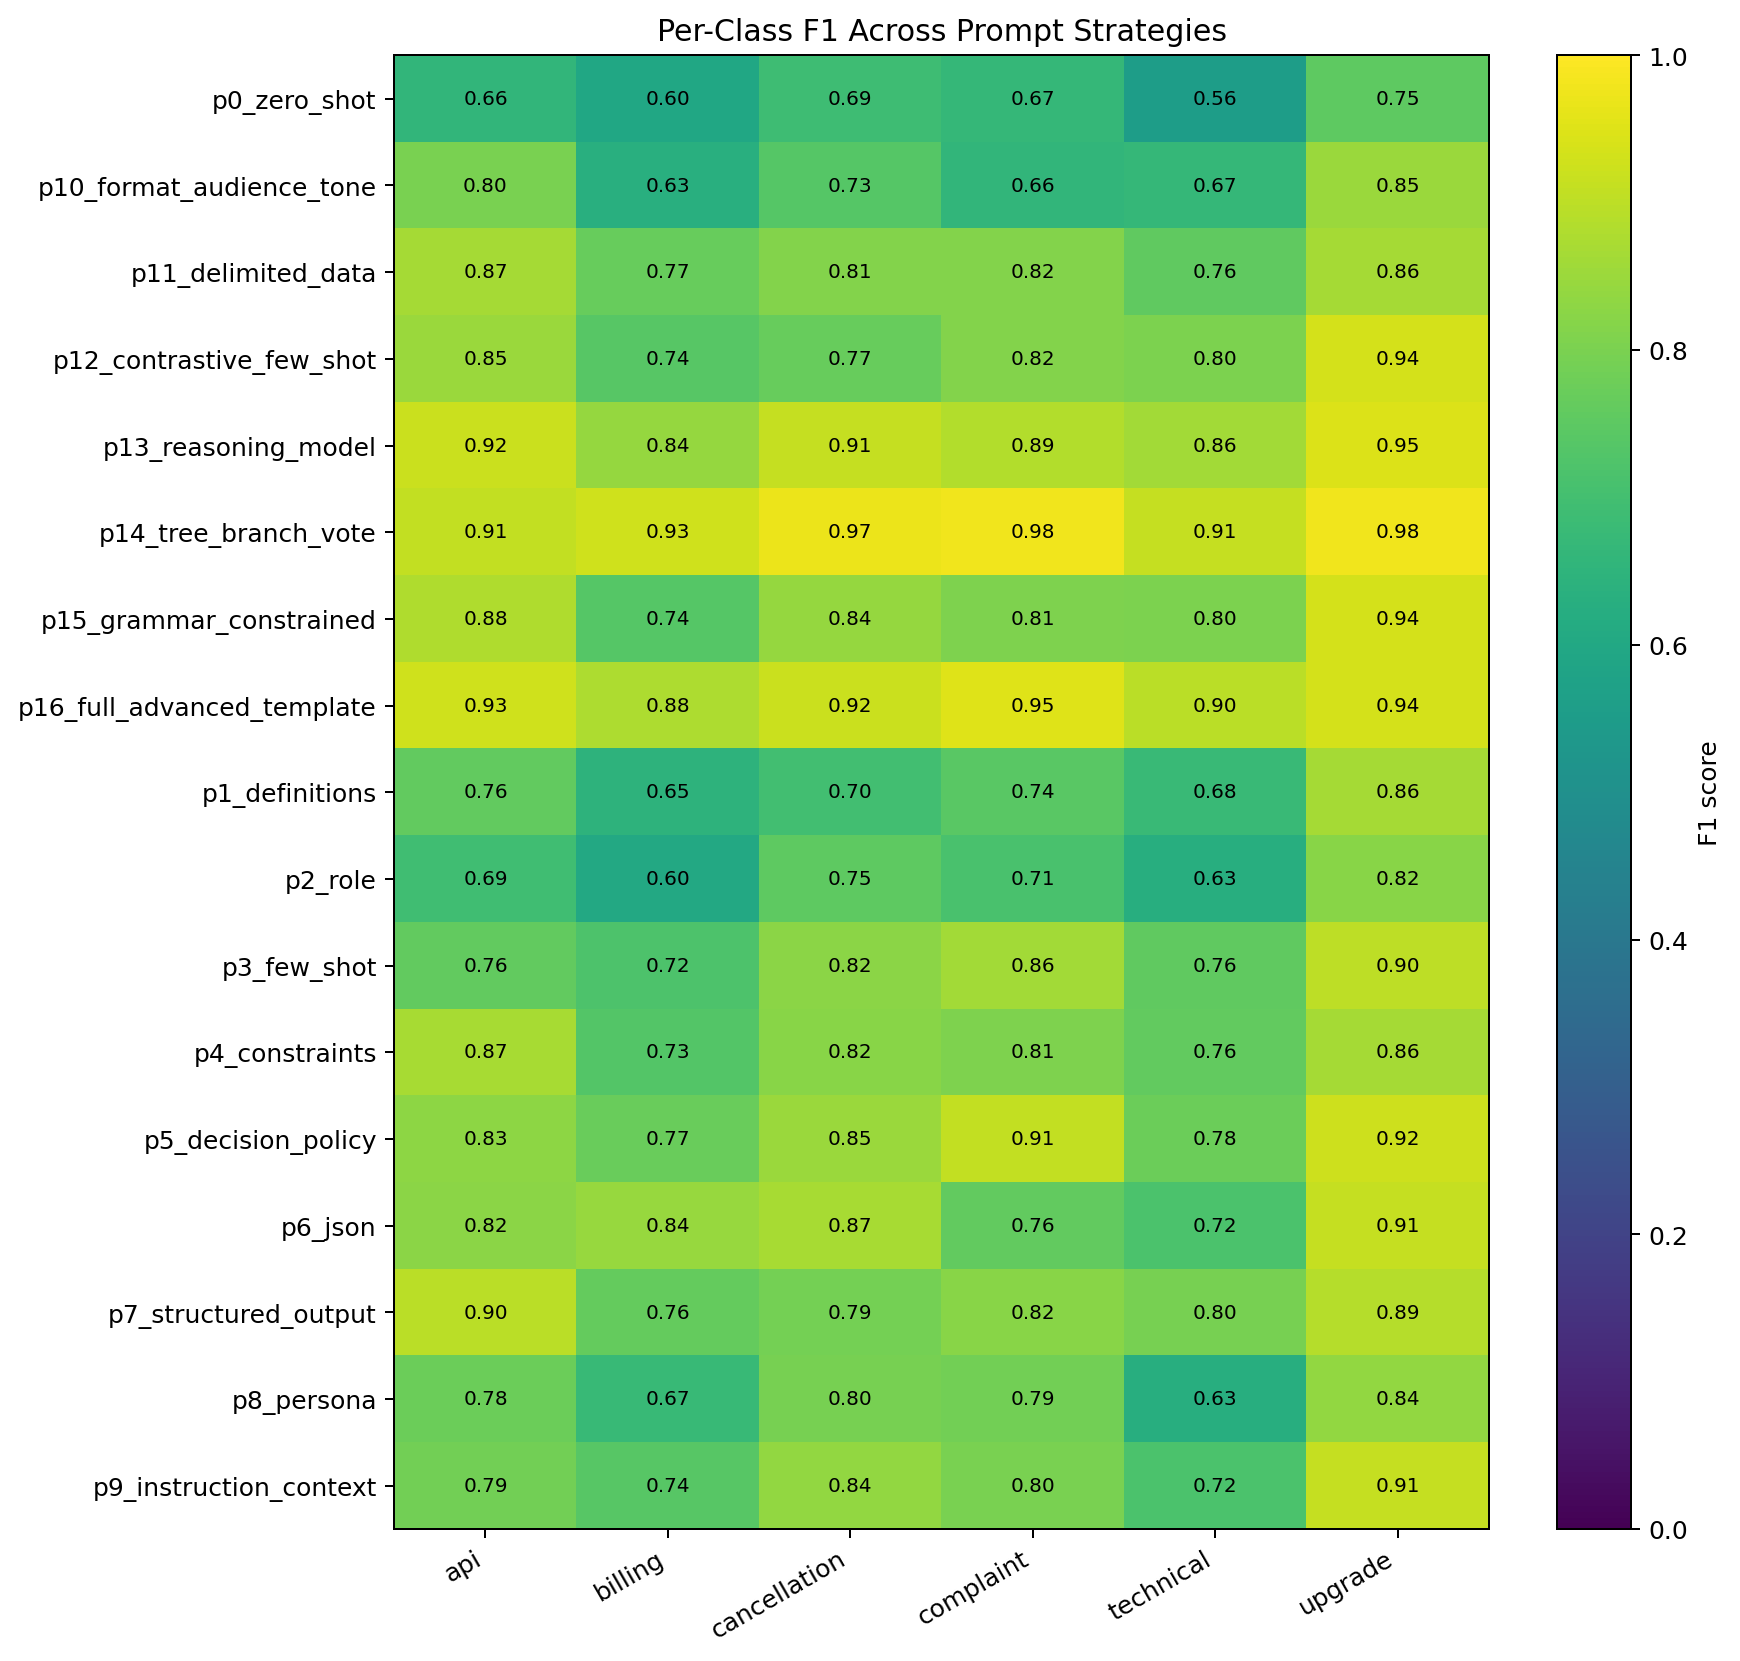

In [10]:
path = PROJECT_ROOT / "07_outputs/reports/figures" / PROVIDER / "12_per_class_f1_heatmap.png"
if path.exists():
    display(Image(filename=str(path)))


### Példa értelmezés

Ha a definitions prompt főként az `api` F1-et javítja, az alátámaszthatja azt a hipotézist, hogy a label szemantikája korábban nem volt elég egyértelmű. Ha minden class ugyanúgy marad, akkor a plusz prompt token valószínűleg kevés értéket adott.

## 8. Error rate true class szerint

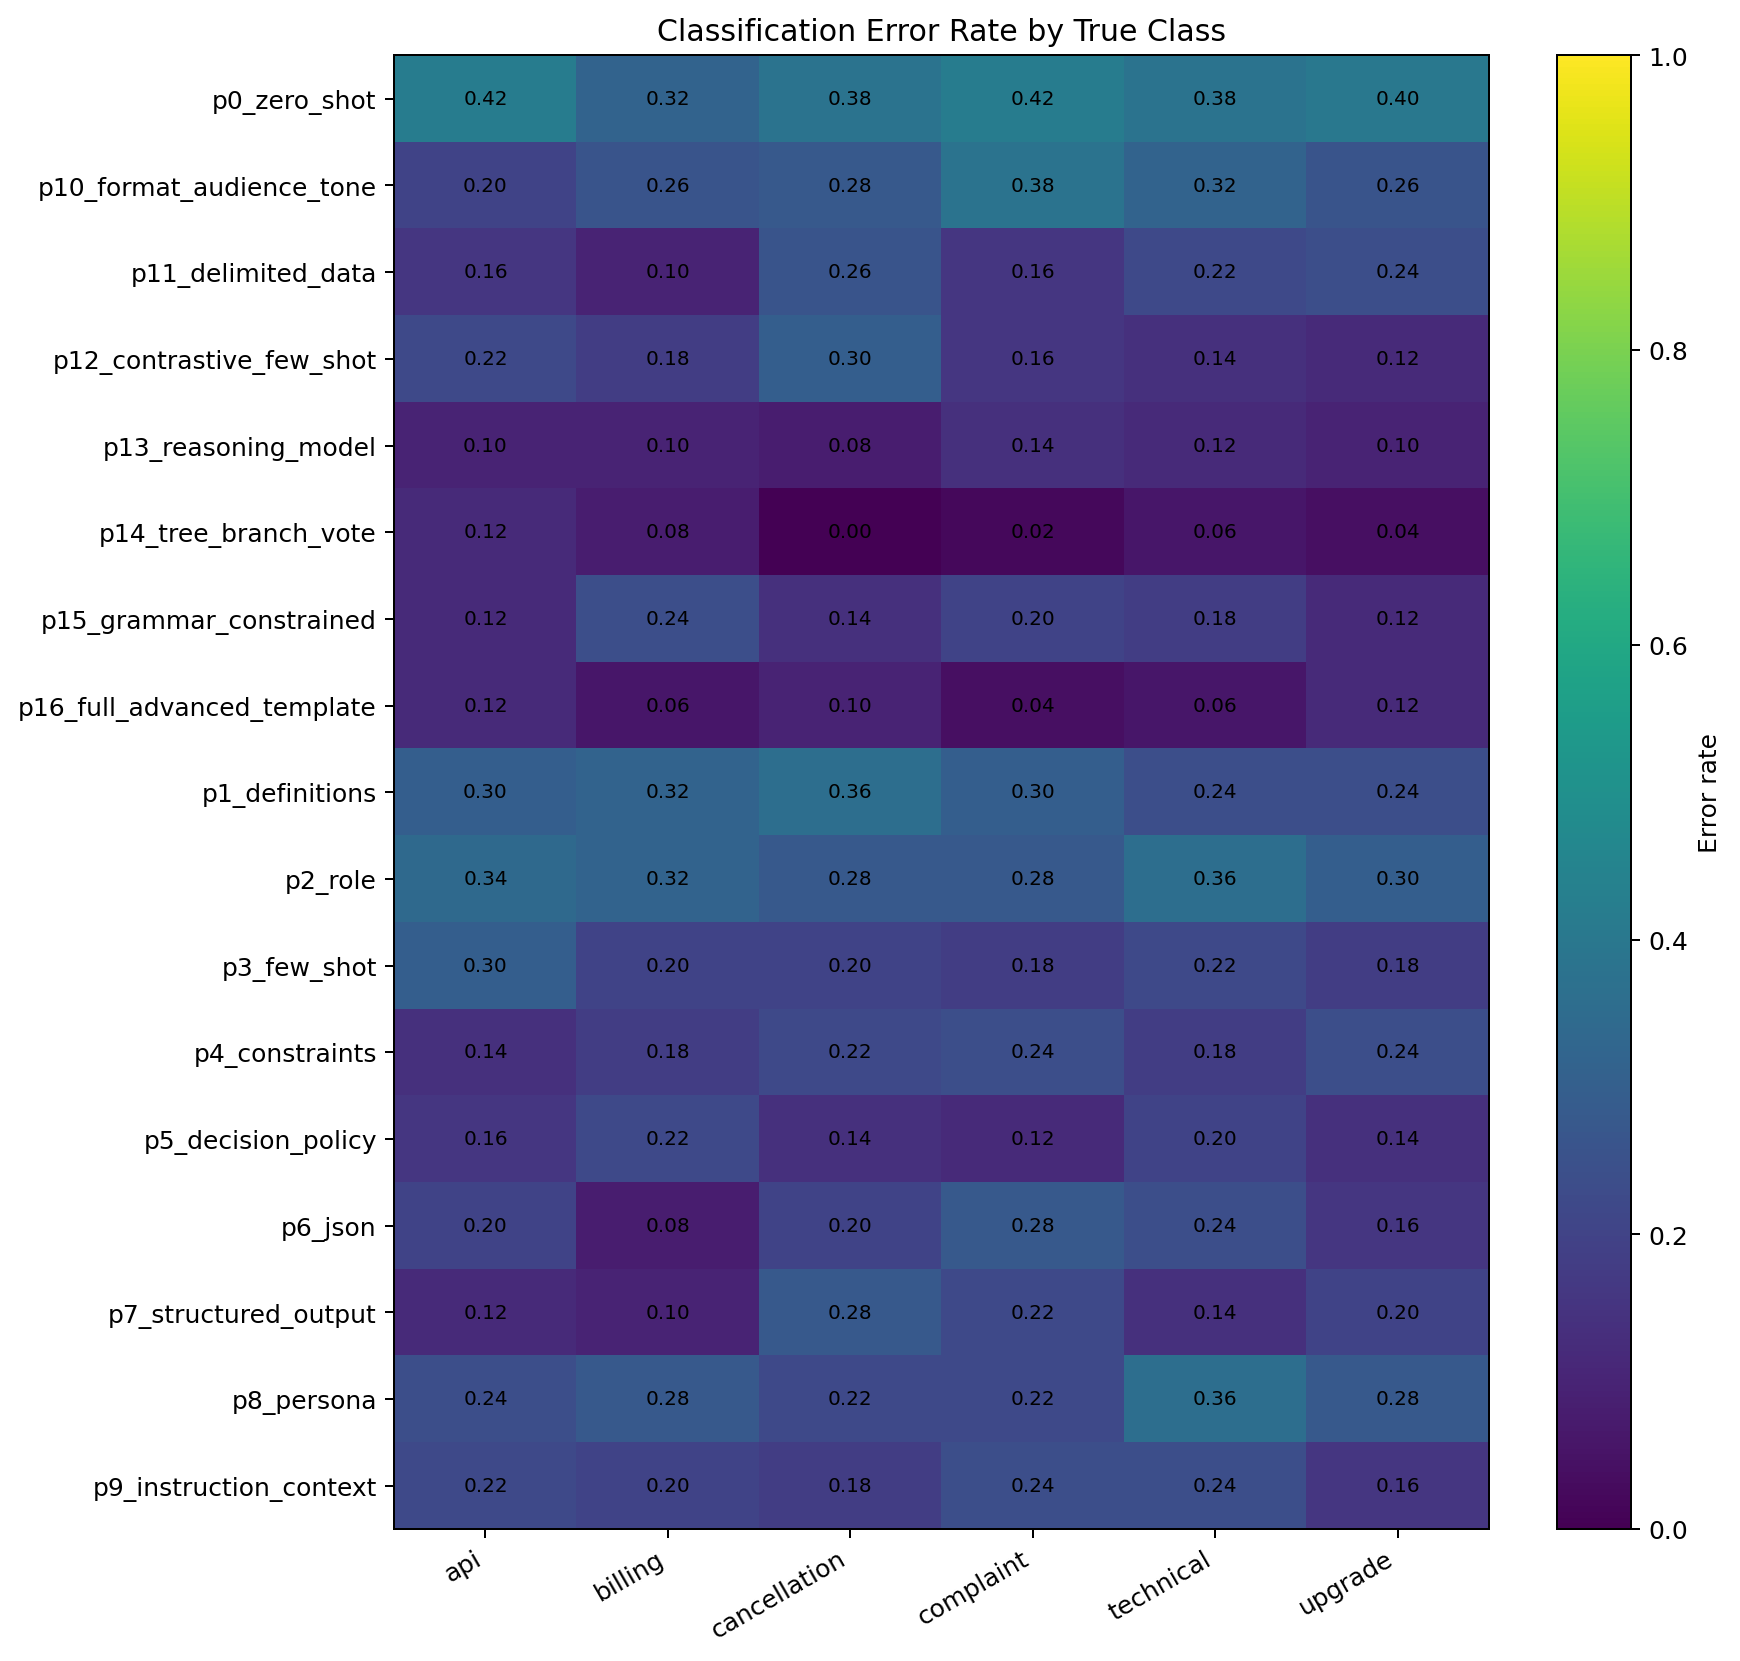

In [11]:
path = PROJECT_ROOT / "07_outputs/reports/figures" / PROVIDER / "13_error_rate_by_class.png"
if path.exists():
    display(Image(filename=str(path)))


## 9. Legnehezebb benchmark példák

A `hard_examples.csv` azt számolja meg, hány stratégia rontotta el ugyanazt a sample-t. Ezek a példák jó jelöltek manuális inspectionre és jövőbeli adversarial test set kialakítására.

In [12]:
hard_path = PROJECT_ROOT / "07_outputs/reports/hard_examples.csv"
if hard_path.exists():
    hard = pd.read_csv(hard_path)
    display(hard.head(20))
else:
    print("Hard-example report not found yet.")


Hard-example report not found yet.


## 10. Gyakori label-confusion párok

Nem csak azt számoljuk, hány hiba van, hanem hogy **milyen irányú** a hiba.

In [13]:
candidate_errors = candidate[candidate["predicted_label"] != candidate["true_label"]]
confusions = (
    candidate_errors.groupby(["true_label", "predicted_label"])
    .size()
    .reset_index(name="count")
    .sort_values("count", ascending=False)
)
confusions.head(20)


,true_label,predicted_label,count
1,api,technical,5
2,billing,cancellation,3
5,technical,api,3
6,upgrade,billing,2
0,api,billing,1
4,complaint,technical,1
3,billing,complaint,1


## 11. Qualitative error taxonomy

A production projekt következő lépése az lenne, hogy a hibákat kézzel is csoportosítsuk például:

- ambiguous intent;
- multiple intents;
- API vs technical boundary;
- billing vs cancellation boundary;
- complaint fallback problem;
- insufficient context;
- formatting/parsing failure.

Ezt azért nem automatizáljuk vakon LLM-as-a-judge-dzsal, mert az új értékelő modell újabb bizonytalansági forrást hozna a kontrollált benchmarkba.

## 12. Döntési szabály

A promptot nem azért tartjuk meg, mert „szebben hangzik”, hanem akkor, ha:

- több hibát javít, mint amennyi regressziót létrehoz;
- a kritikus classok nem romlanak elfogadhatatlanul;
- output reliability javul vagy legalább nem romlik;
- a quality gain arányban áll a token/cost/latency többlettel.

A következő notebookban ablation studyval azt vizsgáljuk, mely promptkomponensek valóban szükségesek.